In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("../../data/processed/final_dataset_clean.csv")
print(df.columns)

Index(['cluster_id', 'household_id', 'child_age_months', 'child_sex',
       'breastfeeding', 'haz_score', 'waz_score', 'whz_score', 'stunted',
       'underweight', 'wasted', 'mother_education', 'urban_rural', 'district',
       'wealth_index', 'disability', 'province', 'birth_weight_known',
       'housing_quality', 'water_source', 'sanitation_type', 'education_level',
       'household_education'],
      dtype='object')


In [8]:
multi_cols = [
    'cluster_id', 'household_id', 'child_age_months', 'child_sex',
    'birth_weight_known','breastfeeding', 'haz_score', 'waz_score', 
    'whz_score', 'stunted', 'underweight', 'wasted', 
    'mother_education', 'urban_rural', 'district', 
    'wealth_index', 'disability', 'province'
]

# Create a subset for analysis
df_multi = df[multi_cols]

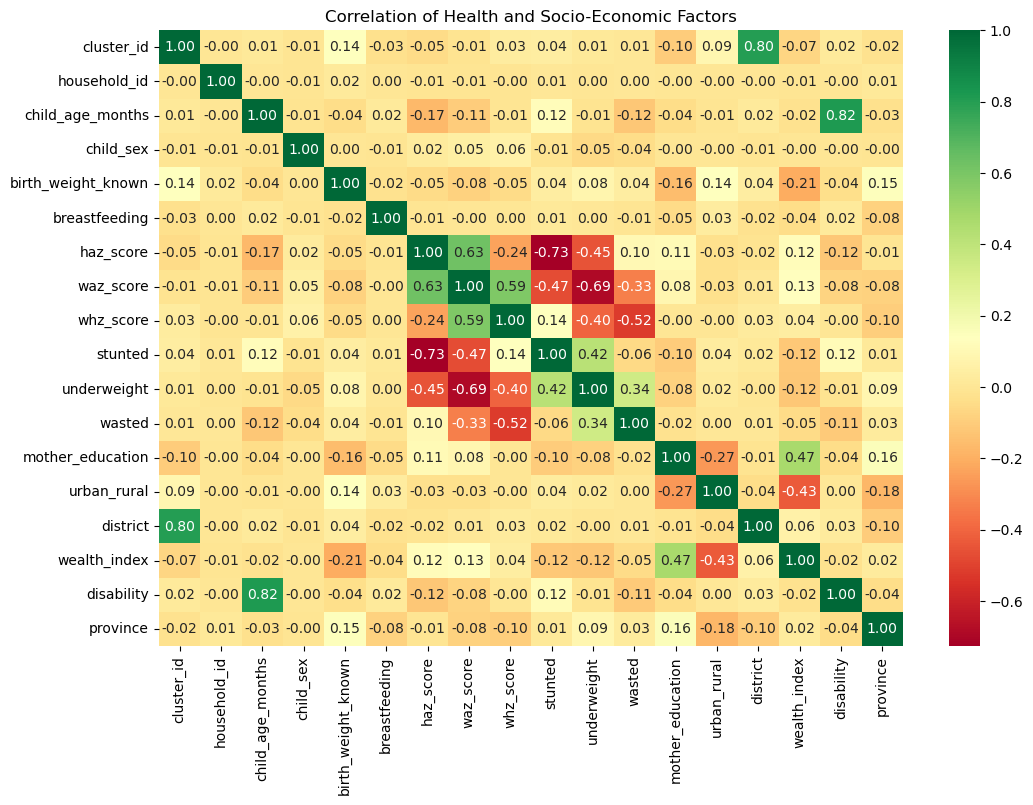

In [9]:
plt.figure(figsize=(12, 8))
# Calculating correlation for numeric types only
corr = df_multi.select_dtypes(include=['number']).corr()
sns.heatmap(corr, annot=True, cmap='RdYlGn', fmt=".2f")
plt.title("Correlation of Health and Socio-Economic Factors")
plt.show()

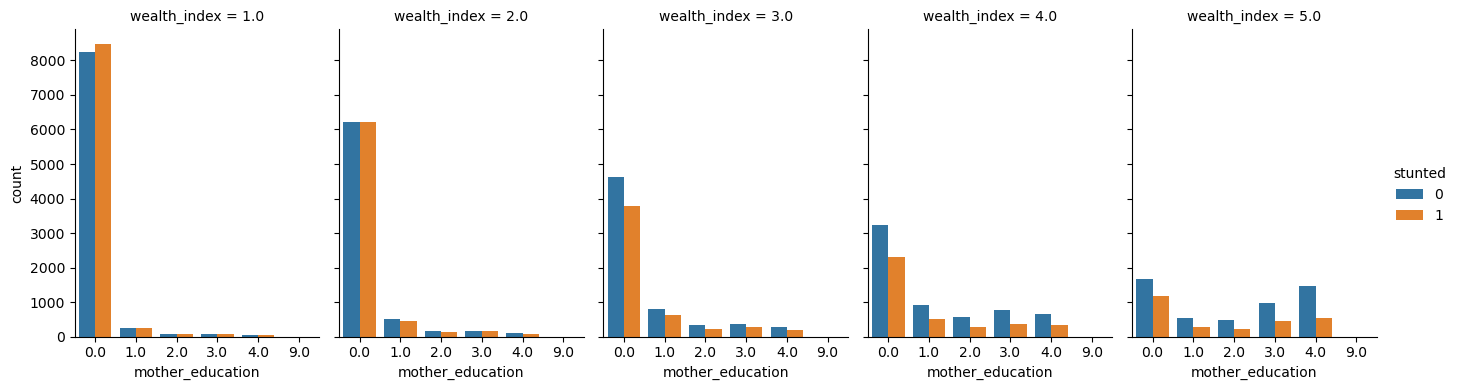

In [10]:
# Grouping by wealth and education to see stunting percentages
sns.catplot(
    data=df_multi, 
    x='mother_education', 
    hue='stunted', 
    col='wealth_index', 
    kind='count', 
    height=4, aspect=0.7
)
plt.show()

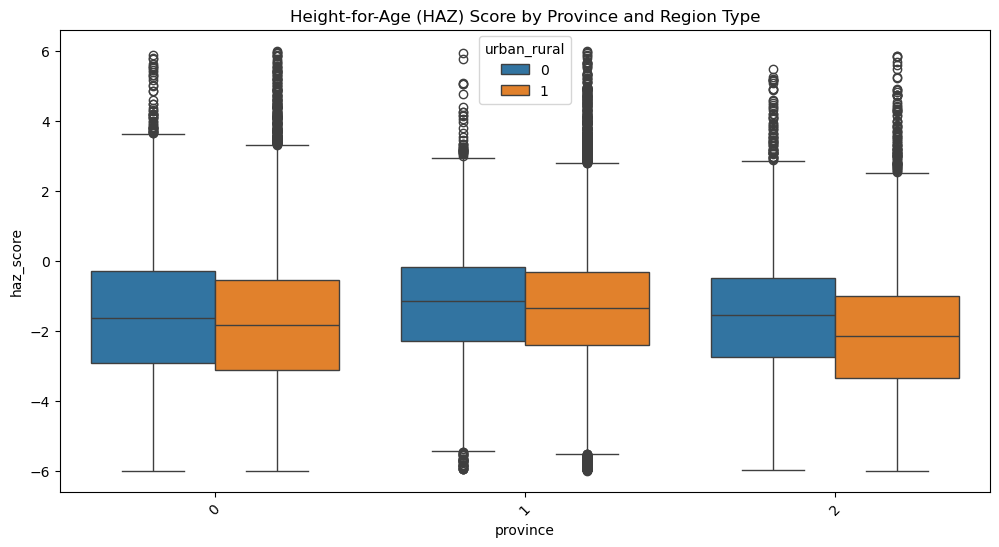

In [11]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_multi, x='province', y='haz_score', hue='urban_rural')
plt.title("Height-for-Age (HAZ) Score by Province and Region Type")
plt.xticks(rotation=45)
plt.show()

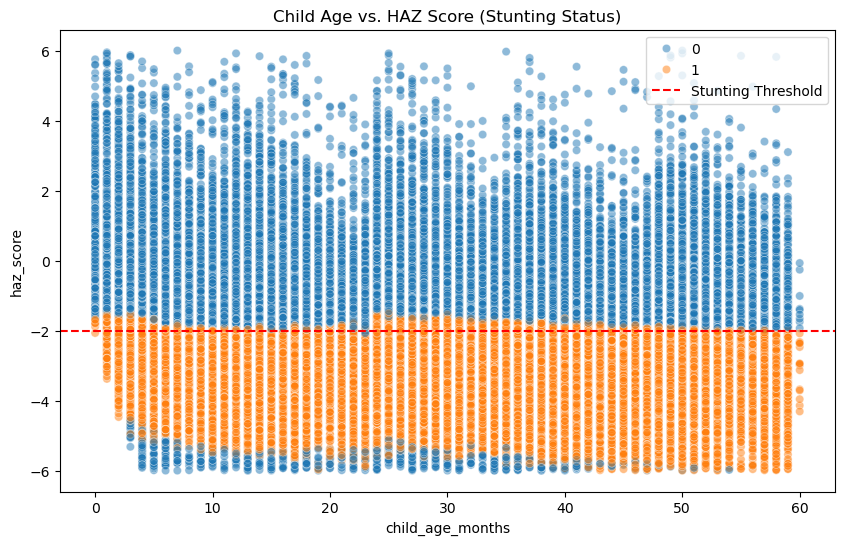

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_multi, x='child_age_months', y='haz_score', hue='stunted', alpha=0.5)
plt.axhline(y=-2, color='red', linestyle='--', label='Stunting Threshold')
plt.title("Child Age vs. HAZ Score (Stunting Status)")
plt.legend()
plt.show()

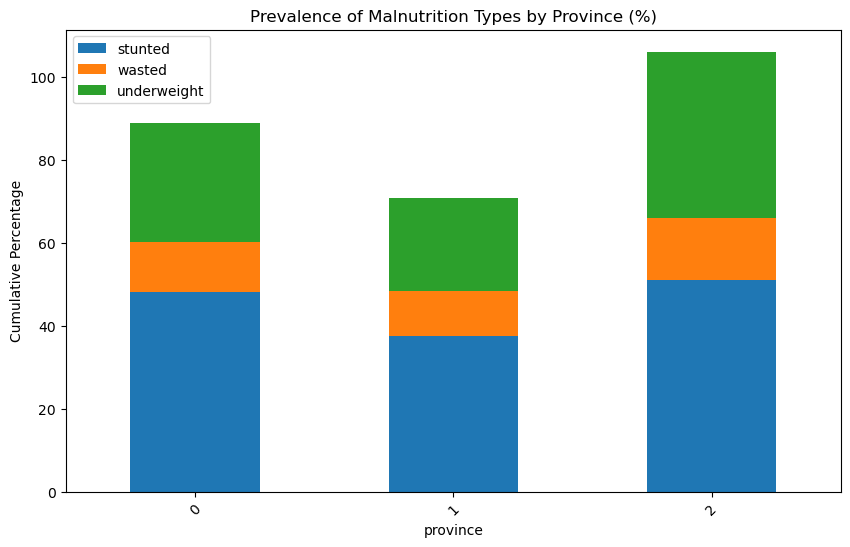

In [13]:
# Create a summary table for the provinces
prov_summary = df_multi.groupby('province')[['stunted', 'wasted', 'underweight']].mean() * 100

prov_summary.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title("Prevalence of Malnutrition Types by Province (%)")
plt.ylabel("Cumulative Percentage")
plt.xticks(rotation=45)
plt.show()

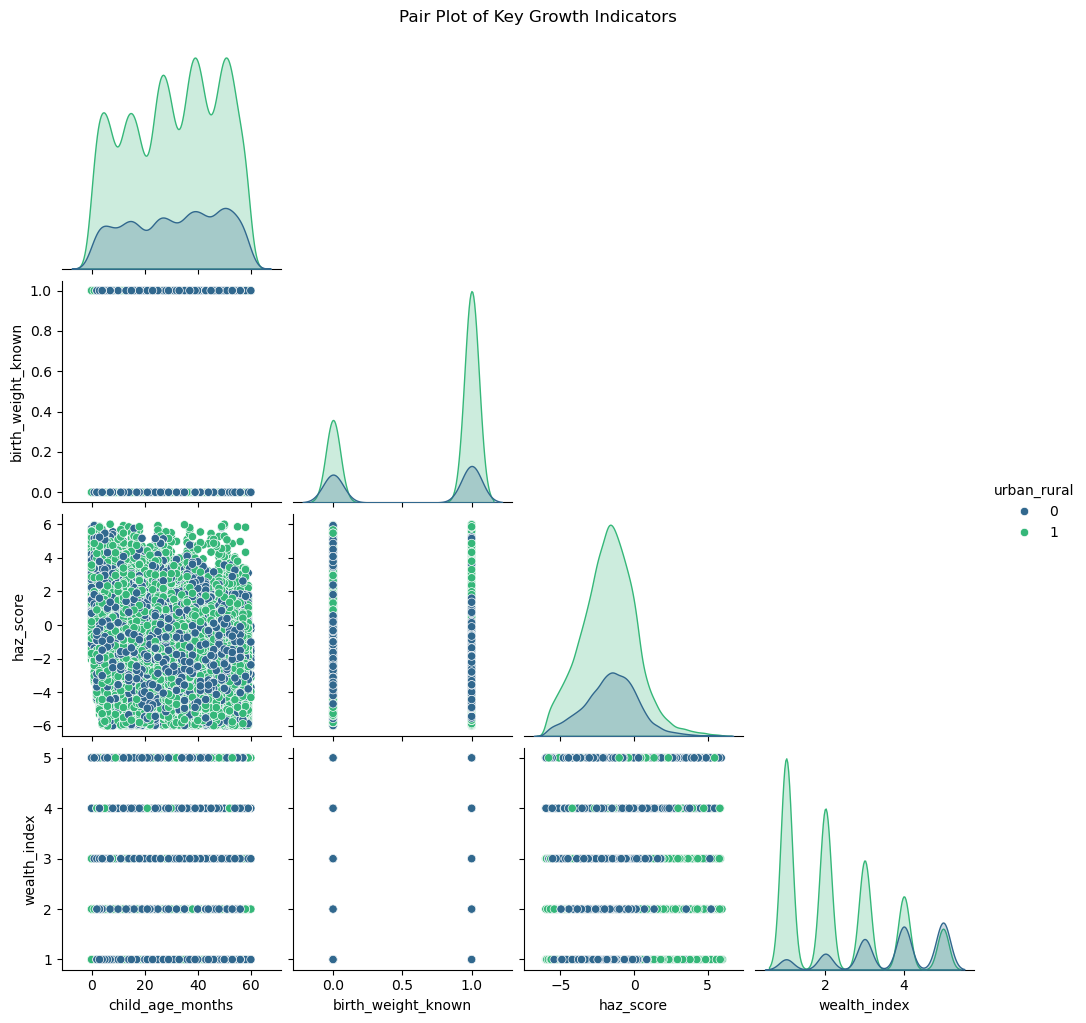

In [15]:
# Selecting key numeric variables to avoid overwhelming the grid
numeric_vars = ['child_age_months', 'birth_weight_known', 'haz_score', 'wealth_index']

sns.pairplot(df_multi[numeric_vars + ['urban_rural']], hue='urban_rural', corner=True, palette='viridis')
plt.suptitle("Pair Plot of Key Growth Indicators", y=1.02)
plt.show()

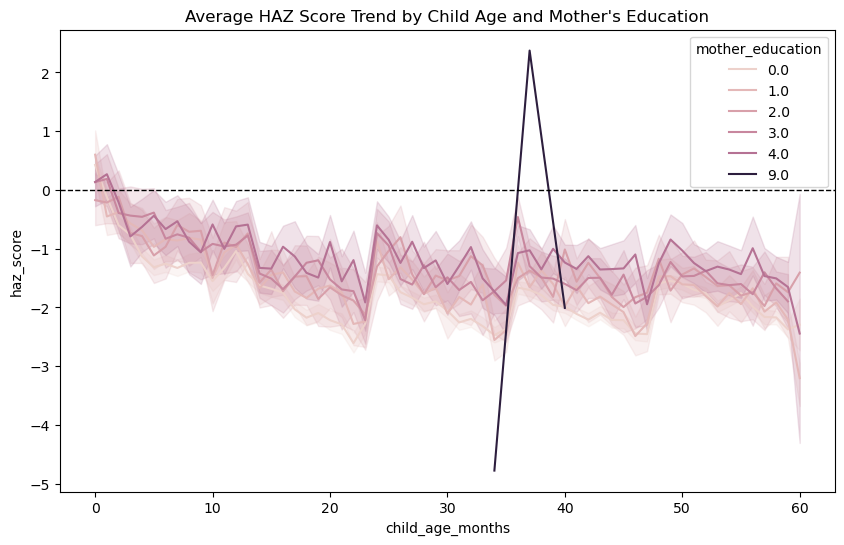

In [18]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_multi, x='child_age_months', y='haz_score', hue='mother_education')
plt.title("Average HAZ Score Trend by Child Age and Mother's Education")
plt.axhline(y=0, color='black', lw=1, ls='--')
plt.show()